29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images shape : (60000, 28, 28)
Test images shape     : (10000, 28, 28)
Pixel value range (raw): 0 - 255
Pixel value range (normalized): 0.0 - 1.0
Reshaped training set : (60000, 28, 28, 1)
Reshaped test set     : (10000, 28, 28, 1)


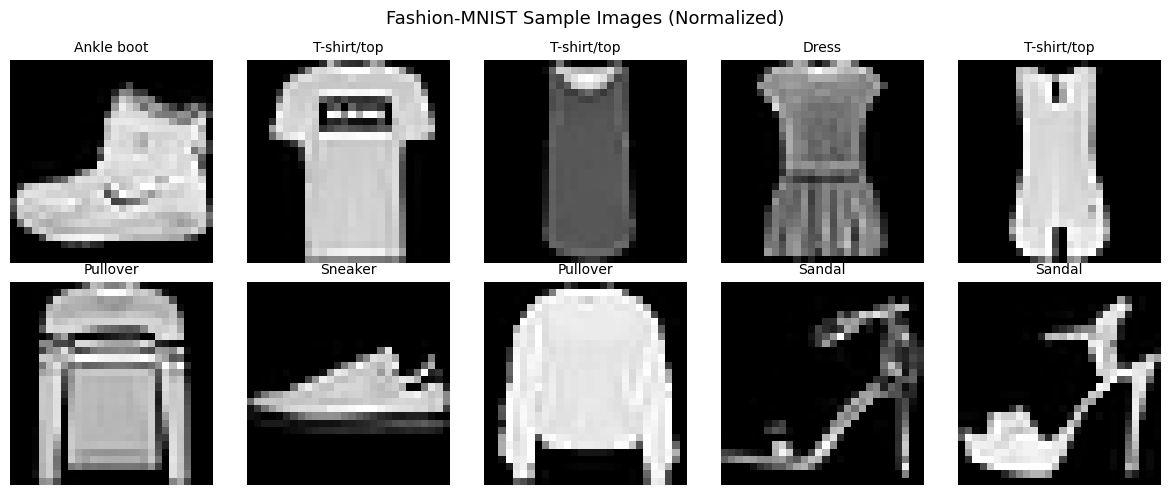

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

# Class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# Load dataset
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print("Training images shape :", x_train.shape)
print("Test images shape     :", x_test.shape)
print("Pixel value range (raw):", x_train.min(), "-", x_train.max())

# Normalize to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0
print("Pixel value range (normalized):", x_train.min(), "-", x_train.max())

# Reshape for CNN: add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test  = x_test.reshape(-1, 28, 28, 1)
print("Reshaped training set :", x_train.shape)
print("Reshaped test set     :", x_test.shape)

# Visualize sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i].reshape(28, 28), cmap='gray')
    ax.set_title(class_names[y_train[i]], fontsize=10)
    ax.axis('off')
plt.suptitle('Fashion-MNIST Sample Images (Normalized)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    # Conv Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    # Conv Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.Dropout(0.25),

    # Flatten + Dense head
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
], name='Fashion_CNN')

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Fashion_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,605,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,701,130 (6.49 MB)

 Trainable params: 1,701,130 (6.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.15,
    verbose=1
)

print(f"\nFinal Training Accuracy  : {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")

Epoch 1/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.8089 - loss: 0.5241 - val_accuracy: 0.8782 - val_loss: 0.3200
Epoch 2/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8746 - loss: 0.3455 - val_accuracy: 0.8907 - val_loss: 0.2909
Epoch 3/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8890 - loss: 0.3021 - val_accuracy: 0.8997 - val_loss: 0.2661
Epoch 4/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8969 - loss: 0.2789 - val_accuracy: 0.9092 - val_loss: 0.2477
Epoch 5/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9040 - loss: 0.2601 - val_accuracy: 0.9151 - val_loss: 0.2261
Epoch 6/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9093 - loss: 0.2481 - val_accuracy: 0.9132 - val_loss: 0.2314
Epoch 7/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9116 - loss: 0.2383 - val_accuracy: 0.9148 - val_loss: 0.2232
Epoch 8/15
797/797 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9156 - loss: 0.2265 - val_accuracy: 

Test Accuracy : 92.28%
Test Loss     : 0.2275
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.88      0.88      1000
     Trouser       0.99      0.99      0.99      1000
    Pullover       0.86      0.90      0.88      1000
       Dress       0.92      0.94      0.93      1000
        Coat       0.88      0.84      0.86      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.79      0.75      0.77      1000
     Sneaker       0.95      0.98      0.97      1000
         Bag       0.98      0.99      0.99      1000
  Ankle boot       0.99      0.95      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



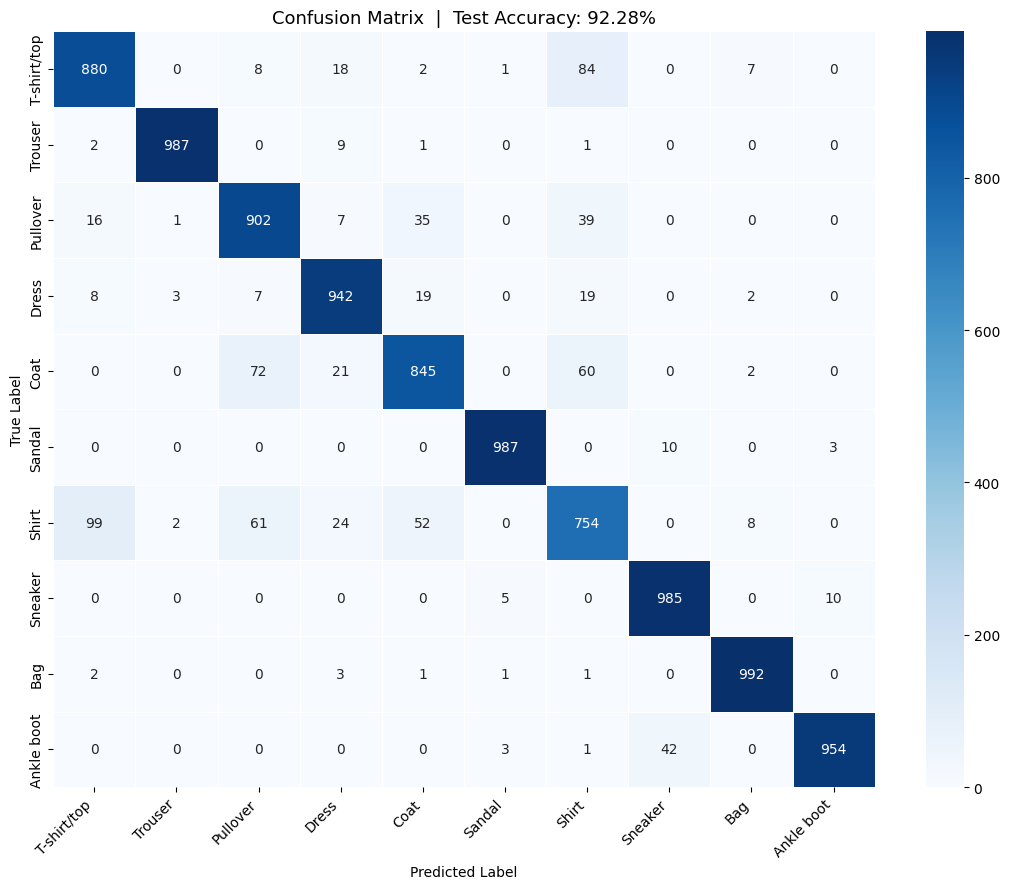

In [ ]:
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Evaluate on test set
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

# Predictions
y_pred = np.argmax(model.predict(x_test), axis=1)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(11, 9))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.5)
plt.title(f'Confusion Matrix  |  Test Accuracy: {test_acc*100:.2f}%', fontsize=13)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

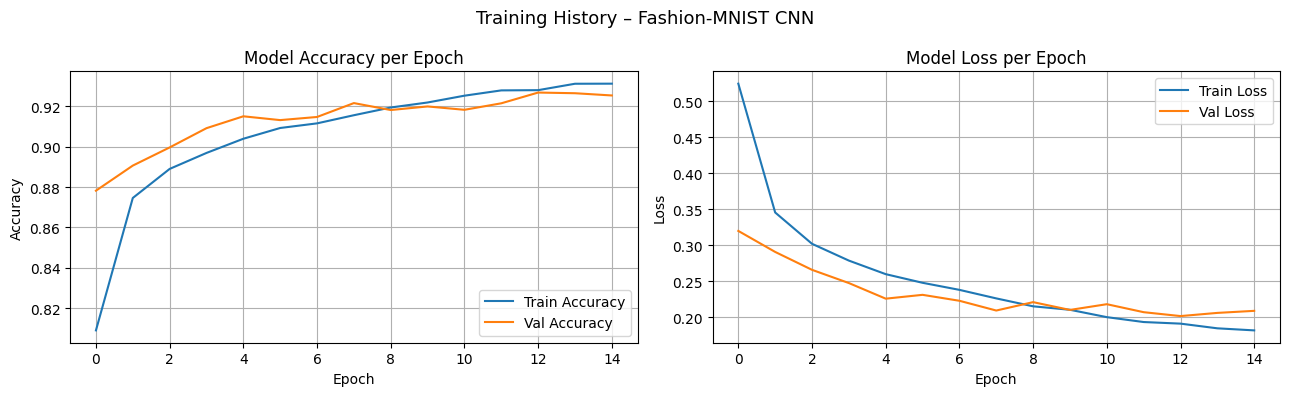

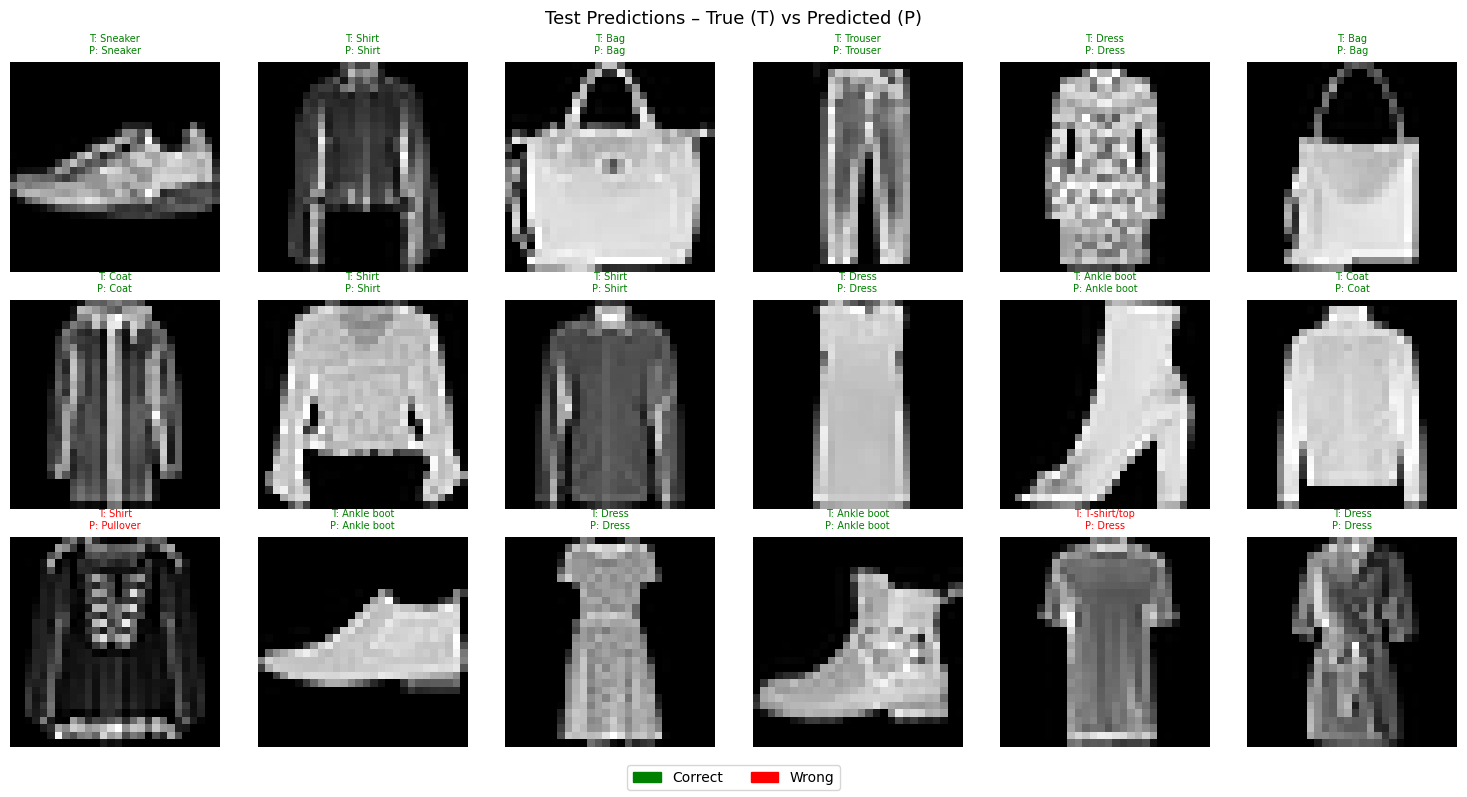

In [ ]:
import matplotlib.patches as mpatches

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history.history['accuracy'],     label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_title('Model Accuracy per Epoch')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'],     label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_title('Model Loss per Epoch')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.suptitle('Training History – Fashion-MNIST CNN', fontsize=13)
plt.tight_layout()
plt.show()

# Sample prediction grid
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
indices = np.random.choice(len(x_test), 18, replace=False)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(x_test[idx].reshape(28, 28), cmap='gray')
    true_lbl = class_names[y_test[idx]]
    pred_lbl = class_names[y_pred[idx]]
    correct  = y_test[idx] == y_pred[idx]
    color    = 'green' if correct else 'red'
    ax.set_title(f"T: {true_lbl}\nP: {pred_lbl}", color=color, fontsize=7)
    ax.axis('off')

green_patch = mpatches.Patch(color='green', label='Correct')
red_patch   = mpatches.Patch(color='red',   label='Wrong')
fig.legend(handles=[green_patch, red_patch], loc='lower center', ncol=2, fontsize=10)
plt.suptitle('Test Predictions – True (T) vs Predicted (P)', fontsize=13)
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()